In [63]:
import pandas as pd

df_pretrained = pd.read_pickle('classification_2p2t_finetuned.pkl')
markdown_string = """
| TokenMixer | Kernel Size | ImageWoof              | PathMNIST              | DermaMNIST             | PneumoniaMNIST         | OrganSMNIST            |
|-------------|-------------|------------------------|------------------------|------------------------|------------------------|------------------------|
| pooling     | 3           | 0.7908, 0.9495, 0.7907 | 0.8817, 0.9758, 0.8767 | 0.6828, 0.8883, 0.6868 | 0.9632, 0.9921, 0.9656 | 0.7659, 0.9617, 0.7689 |
|             | 5           | 0.7941, 0.9517, 0.7965 | 0.8832, 0.9799, 0.8773 | 0.6933, 0.8911, 0.6855 | 0.9393, 0.9832, 0.9446 | 0.7494, 0.9375, 0.7576 |
|             | 7           | 0.8044, 0.9539, 0.8059 | 0.903, 0.9829, 0.8986  | 0.6811, 0.8795, 0.6991 | 0.9526, 0.9814, 0.9537 | 0.7649, 0.942, 0.7706  |
| conv        | 3           | 0.7659, 0.9466, 0.7657 | 0.8688, 0.9697, 0.8551 | 0.7189, 0.9035, 0.7141 | 0.9346, 0.9755, 0.9425 | 0.7772, 0.9594, 0.7804 |
|             | 5           | 0.7222, 0.9191, 0.7243 | 0.8812, 0.9785, 0.8735 | 0.6675, 0.8456, 0.6869 | 0.9286, 0.9841, 0.9386 | 0.7897, 0.9611, 0.7921 |
|             | 7           | 0.6737, 0.9036, 0.6752 | 0.9159, 0.9862, 0.9145 | 0.6583, 0.8526, 0.6774 | 0.9423, 0.9864, 0.9496 | 0.7742, 0.9671, 0.7789 |
| grouped conv    | 3           | 0.7599, 0.9357, 0.7616 | 0.8629, 0.9708, 0.8538 | 0.7121, 0.8865, 0.7174 | 0.9607, 0.9894, 0.9654 | 0.7906, 0.9468, 0.7922 |
|             | 5           | 0.7155, 0.9208, 0.7166 | 0.9122, 0.9826, 0.9066 | 0.6891, 0.8793, 0.6845 | 0.9534, 0.9895, 0.9569 | 0.7744, 0.9474, 0.7798 |
|             | 7           | 0.6822, 0.9089, 0.6836 | 0.9011, 0.9846, 0.8991 | 0.6821, 0.8607, 0.7012 | 0.9261, 0.9857, 0.9353 | 0.79, 0.9506, 0.7918   |
| local attn     | 3           | 0.5239, 0.8796, 0.5225 | 0.8611, 0.9771, 0.8529 | 0.6295, 0.9168, 0.5749 | 0.9038, 0.9716, 0.9083 | 0.7525, 0.9702, 0.7562 |
|             | 5           | 0.4898, 0.8691, 0.4881 | 0.8186, 0.969, 0.8074  | 0.6082, 0.9179, 0.5452 | 0.9128, 0.9734, 0.9171 | 0.7576, 0.9721, 0.7598 |
|             | 7           | 0.4817, 0.862, 0.4783  | 0.8218, 0.9733, 0.8096 | 0.6084, 0.923, 0.5553  | 0.903, 0.9665, 0.9082  | 0.7411, 0.9701, 0.7447 |
| global attn    | -           | 0.5502, 0.8907, 0.5486 | 0.8596, 0.9823, 0.847  | 0.6597, 0.9328, 0.5944 | 0.8389, 0.9638, 0.8582 | 0.7641, 0.9686, 0.7646 |
| identity    | 1           | 0.7831, 0.9659, 0.7852 | 0.778, 0.956, 0.7465   | 0.7062, 0.9474, 0.7106 | 0.9483, 0.9892, 0.9533 | 0.7761, 0.9637, 0.775  |
"""

lines = markdown_string.split("\n")
header = lines[1].strip("|").split("|")
header = list(map(lambda s: s.strip(), header))

data = []

# Loop through lines starting from 2
for line in lines[3:]:

    # Break once we hit an empty line
    if not line.strip():
        break

    cols = line.strip("|").split("|")
    cols = map(lambda s: s.strip(), cols)
    row = dict(zip(header, cols))
    data.append(row)

df_scratch = pd.DataFrame(data)
df_scratch.iloc[:, 0] = df_scratch.iloc[:, 0].replace("", pd.NA).ffill()
df_scratch.set_index(['TokenMixer', 'Kernel Size'], inplace=True)

df_scratch = df_scratch.apply(lambda col: col.str.split(","))
df_scratch = pd.concat(
    [df_scratch[col].apply(pd.Series).add_prefix(f"{col.strip()}_") for col in df_scratch.columns],
    axis=1
)

suffix_map = {
    "_0": "_acc",
    "_1": "_auc",
    "_2": "_f1"
}
df_scratch = df_scratch.rename(columns=lambda col: next((col.replace(k, v) for k, v in suffix_map.items() if k in col), col))
df_scratch = df_scratch.apply(pd.to_numeric, errors="coerce")
df_scratch

ImageWoof_acc  ImageWoof_auc  ImageWoof_f1  \
TokenMixer   Kernel Size                                               
pooling      3                   0.7908         0.9495        0.7907   
             5                   0.7941         0.9517        0.7965   
             7                   0.8044         0.9539        0.8059   
conv         3                   0.7659         0.9466        0.7657   
             5                   0.7222         0.9191        0.7243   
             7                   0.6737         0.9036        0.6752   
grouped conv 3                   0.7599         0.9357        0.7616   
             5                   0.7155         0.9208        0.7166   
             7                   0.6822         0.9089        0.6836   
local attn   3                   0.5239         0.8796        0.5225   
             5                   0.4898         0.8691        0.4881   
             7                   0.4817         0.8620        0.4783   
global attn  -                   0.5502         0.8907        0.5486   
identity     1                   0.7831         0.9659        0.7852   

                          PathMNIST_acc  PathMNIST_auc  PathMNIST_f1  \
TokenMixer   Kernel Size                                               
pooling      3                   0.8817         0.9758        0.8767   
             5                   0.8832         0.9799        0.8773   
             7                   0.9030         0.9829        0.8986   
conv         3                   0.8688         0.9697        0.8551   
             5                   0.8812         0.9785        0.8735   
             7                   0.9159         0.9862        0.9145   
grouped conv 3                   0.8629         0.9708        0.8538   
             5                   0.9122         0.9826        0.9066   
             7                   0.9011         0.9846        0.8991   
local attn   3                   0.8611         0.9771        0.8529   
             5                   0.8186         0.9690        0.8074   
             7                   0.8218         0.9733        0.8096   
global attn  -                   0.8596         0.9823        0.8470   
identity     1                   0.7780         0.9560        0.7465   

                          DermaMNIST_acc  DermaMNIST_auc  DermaMNIST_f1  \
TokenMixer   Kernel Size                                                  
pooling      3                    0.6828          0.8883         0.6868   
             5                    0.6933          0.8911         0.6855   
             7                    0.6811          0.8795         0.6991   
conv         3                    0.7189          0.9035         0.7141   
             5                    0.6675          0.8456         0.6869   
             7                    0.6583          0.8526         0.6774   
grouped conv 3                    0.7121          0.8865         0.7174   
             5                    0.6891          0.8793         0.6845   
             7                    0.6821          0.8607         0.7012   
local attn   3                    0.6295          0.9168         0.5749   
             5                    0.6082          0.9179         0.5452   
             7                    0.6084          0.9230         0.5553   
global attn  -                    0.6597          0.9328         0.5944   
identity     1                    0.7062          0.9474         0.7106   

                          PneumoniaMNIST_acc  PneumoniaMNIST_auc  \
TokenMixer   Kernel Size                                           
pooling      3                        0.9632              0.9921   
             5                        0.9393              0.9832   
             7                        0.9526              0.9814   
conv         3                        0.9346              0.9755   
             5                        0.9286              0.9841   
             7                        0.942

In [64]:
# Select all rows under "locAttn"
locattn_rows = df_scratch.xs('local attn', level=0, drop_level=False)

# Build new MultiIndex with the new label
new_index = pd.MultiIndex.from_product(
    [['local attn (warm start)'], locattn_rows.index.get_level_values(1)],
    names=df_scratch.index.names
)

# Reindex the rows with the new MultiIndex
locattn_rows = locattn_rows.set_index(new_index)

# Append to original df
df_scratch = pd.concat([df_scratch, locattn_rows])

In [65]:
row = df_scratch.loc[('global attn', '-')].copy()
row.name = ('global attn (warm start)', '-')
df_scratch = pd.concat([df_scratch, row.to_frame().T])

In [66]:
df_scratch.loc[('global attn (warm start)', '-')] = df_scratch.loc[('global attn', '-')]

In [67]:
df_scratch.index.names = ['TokenMixer', 'Kernel Size']
df_join = pd.merge(df_scratch, df_pretrained, on=['TokenMixer', 'Kernel Size'], suffixes=('_scratch', '_pretrained'))

In [68]:
df = pd.DataFrame()
for p in df_scratch.columns:
    df[p] = df_join[f'{p}_pretrained']/df_join[f'{p}_scratch']

df = df.loc[~df.index.get_level_values(0).str.startswith('ResNet'), df.columns.str.endswith('_auc')]
df = df -1
df_no_imgwoof = df.iloc[:, 1:]
df

ImageWoof_auc  PathMNIST_auc  \
TokenMixer               Kernel Size                                 
pooling                  3                 0.015798      -0.016602   
                         5                 0.013029      -0.015104   
                         7                 0.016564      -0.008037   
conv                     3                 0.022607      -0.013716   
                         5                 0.040474      -0.010935   
                         7                 0.063192      -0.014297   
grouped conv             3                 0.030458      -0.009065   
                         5                 0.037793      -0.018828   
                         7                 0.081637      -0.004672   
local attn               3                 0.099477      -0.002661   
                         5                 0.110804       0.005366   
                         7                 0.121346       0.000308   
global attn              -                 0.082968      -0.002443   
identity                 1                 0.018739      -0.005126   
local attn (warm start)  3                 0.105389      -0.001842   
                         5                 0.139570       0.004025   
                         7                 0.150696       0.006473   
global attn (warm start) -                 0.113731       0.002443   

                                      DermaMNIST_auc  PneumoniaMNIST_auc  \
TokenMixer               Kernel Size                                       
pooling                  3                  0.020376           -0.009172   
                         5                  0.031422            0.005187   
                         7                  0.045821           -0.002140   
conv                     3                  0.010183            0.007893   
                         5                  0.079943            0.002032   
                         7                  0.072367            0.001622   
grouped conv             3                  0.015228            0.001213   
                         5                  0.028773            0.002324   
                         7                  0.047287            0.000710   
local attn               3                 -0.007744            0.008748   
                         5                 -0.014816            0.020649   
                         7                 -0.003575            0.009312   
global attn              -                 -0.030232            0.025835   
identity                 1                  0.018155            0.001921   
local attn (warm start)  3                 -0.015052            0.010086   
                         5                 -0.016015            0.018389   
                         7                 -0.021885            0.023694   
global attn (warm start) -                 -0.027980            0.028740   

                                      OrganSMNIST_auc  
TokenMixer               Kernel Size                   
pooling                  3                  -0.008423  
                         5                   0.025920  
                         7                   0.005839  
conv                     3                  -0.005107  
                         5                  -0.000208  
                         7                  -0.010754  
grouped conv             3                  -0.002957  
                         5                   0.007494  
                         7                  -0.007153  
local attn               3                  -0.021954  
                         5                  -0.015739  
                         7                  -0.015153  
global attn              -                  -0.017964  
identity                 1                  -0.006537  
local attn (warm start)  3                  -0.012369  
                         5                  -0.027981  
                         7                  -0.007937  
global attn (warm start) -                  -0.03840

# Mean Dataset

In [69]:
df.mean(0).sort_values(ascending=False)

ImageWoof_auc         0.070237
DermaMNIST_auc        0.012903
PneumoniaMNIST_auc    0.008725
PathMNIST_auc        -0.005817
OrganSMNIST_auc      -0.008855
dtype: float64

# Pool Size

In [70]:
df.groupby('Kernel Size').mean()

,ImageWoof_auc,PathMNIST_auc,DermaMNIST_auc,PneumoniaMNIST_auc,OrganSMNIST_auc
Kernel Size,,,,,
-,0.098350,0.000000,-0.029106,0.027288,-0.028185
1,0.018739,-0.005126,0.018155,0.001921,-0.006537
3,0.054746,-0.008777,0.004598,0.003754,-0.010162
5,0.068334,-0.007095,0.021861,0.009716,-0.002103
7,0.086687,-0.004045,0.028003,0.006640,-0.007032


In [71]:
df.groupby('Kernel Size').mean().mean(1).sort_values(ascending=False)

Kernel Size
7    0.022051
5    0.018143
-    0.013669
3    0.008832
1    0.005430
dtype: float64

In [72]:
df_no_imgwoof.groupby('Kernel Size').mean().mean(1).sort_values(ascending=False)

Kernel Size
7    0.005891
5    0.005595
1    0.002103
3   -0.002647
-   -0.007501
dtype: float64

# Token Mixer

In [73]:
df.groupby('TokenMixer').mean()

,ImageWoof_auc,PathMNIST_auc,DermaMNIST_auc,PneumoniaMNIST_auc,OrganSMNIST_auc
TokenMixer,,,,,
conv,0.042091,-0.012983,0.054164,0.003849,-0.005356
global attn,0.082968,-0.002443,-0.030232,0.025835,-0.017964
global attn (warm start),0.113731,0.002443,-0.027980,0.028740,-0.038406
grouped conv,0.049963,-0.010855,0.030429,0.001416,-0.000872
identity,0.018739,-0.005126,0.018155,0.001921,-0.006537
local attn,0.110542,0.001005,-0.008712,0.012903,-0.017615
local attn (warm start),0.131885,0.002885,-0.017651,0.017390,-0.016096
pooling,0.015130,-0.013248,0.032540,-0.002042,0.007779


In [74]:
df.groupby('TokenMixer').mean().mean(1).sort_values(ascending=False)

TokenMixer
local attn (warm start)     0.023683
local attn                  0.019625
conv                        0.016353
global attn (warm start)    0.015706
grouped conv                0.014016
global attn                 0.011633
pooling                     0.008032
identity                    0.005430
dtype: float64

In [75]:
df_no_imgwoof.groupby('TokenMixer').mean().mean(1).sort_values(ascending=False)

TokenMixer
conv                        0.009919
pooling                     0.006257
grouped conv                0.005030
identity                    0.002103
local attn                 -0.003105
local attn (warm start)    -0.003368
global attn                -0.006201
global attn (warm start)   -0.008801
dtype: float64

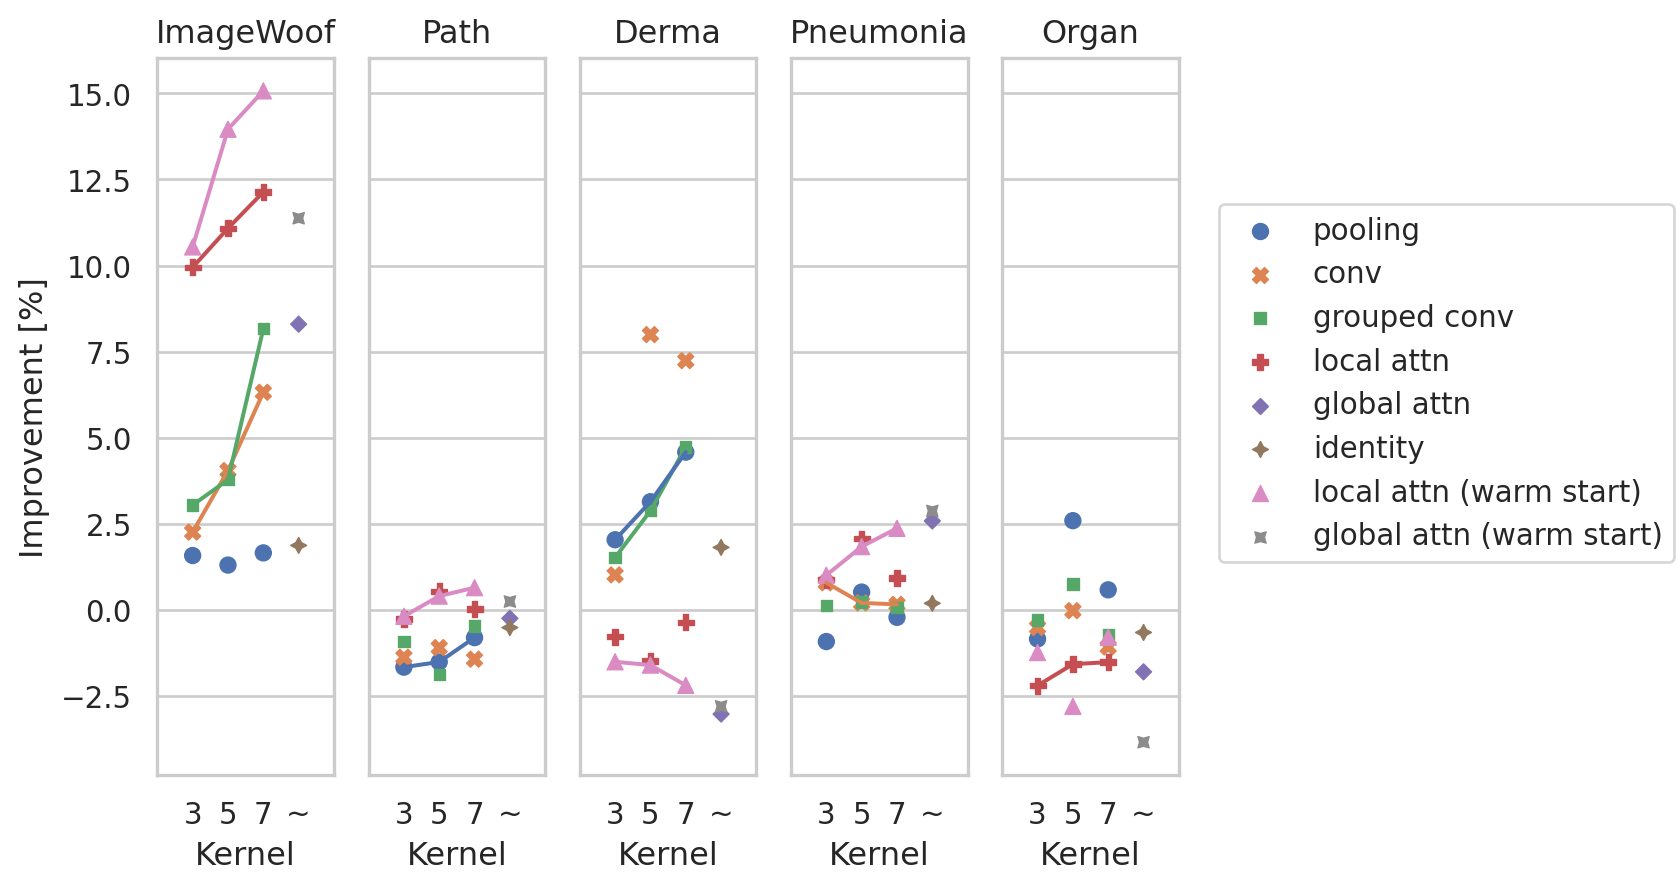

In [76]:
import seaborn as sns
from seaborn import objects as so

df_long = df.copy()
df_long.columns = df_long.columns.str.rstrip('_auc')
df_long.columns = df_long.columns.str.rstrip('MNIST')
df_long = df_long.reset_index().melt(id_vars=["TokenMixer", "Kernel Size"], var_name="dataset", value_name="improvement")

df_long.loc[df_long['Kernel Size'].isin(['1', '-']), 'Kernel Size'] = '~'
df_long['improvement'] *= 100

df_lines = df_long.query(' or '.join([
    "dataset == 'ImageWoof' and TokenMixer.isin(['local attn (warm start)', 'local attn', 'grouped conv', 'conv'])",
    "dataset == 'Path' and TokenMixer.isin(['pooling', 'local attn (warm start)'])",
    "dataset == 'Derma' and TokenMixer.isin(['pooling', 'grouped conv', 'local attn (warm start)'])",
    "dataset == 'Pneumonia' and TokenMixer.isin(['local attn (warm start)', 'conv'])",
    "dataset == 'Organ' and TokenMixer.isin(['local attn'])",
]))

(
    so.Plot(df_long, x="Kernel Size", y="improvement", color="TokenMixer")
    .facet(col="dataset")
    .theme(sns.axes_style("whitegrid"))
    .add(so.Line(), data=df_lines, legend=False)
    .add(so.Dot(), marker='TokenMixer')
    .limit(x=(-1, 4))
    .layout(engine='tight')
    .label(y='Improvement [%]', x='Kernel', color='')
    .save(f'uplift.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
)

ValueError: Unrecognized marker style 'Token Mixer'

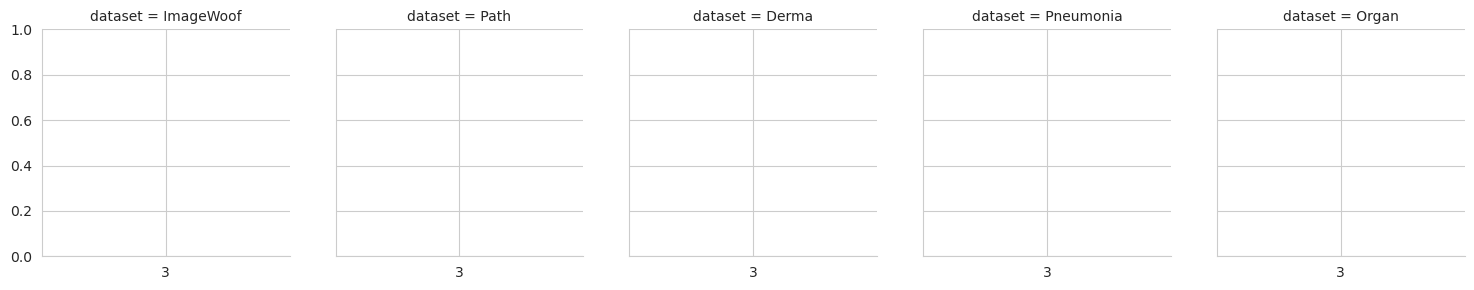

In [77]:
g = sns.FacetGrid(df_long, col="dataset")
g.map_dataframe(sns.lineplot, x='Kernel Size', y='improvement', marker='Token Mixer')